KEJADIAN LANGKA DENGAN GENESIS DI ZONA EKUATORIAL
          SID   NAME  SEASON            ISO_TIME  LAT   LON
2001361N01106  VAMEI    2001 2001-12-26 12:00:00  1.4 106.2
2025330N05099 SENYAR    2025 2025-11-25 12:00:00  4.8  99.0

Jumlah rare event = 2

TABEL 3.9 - KONDISI METEOROLOGIS PADA GENESIS
          SID Siklon  Tahun  Latitude Genesis  Longitude Genesis  Cluster  SST (°C)  TP (mm)  ω (Pa/s)  Vortisitas (×10⁻⁵ s⁻¹)  Wind (km/jam)  Pressure (hPa)  Coriolis (×10⁻⁵ s⁻¹)
2001361N01106  VAMEI   2001               1.4              106.2        2    27.498    2.967    -0.265                  15.724           45.0          1005.0                 0.356
2025330N05099 SENYAR   2025               4.8               99.0        2    28.518   20.044    -3.540                  55.239           65.0           999.0                 1.220

TABEL 3.10 - RINGKASAN PERKEMBANGAN
Siklon  Tahun  Durasi (jam)  Panjang Trajektori (km)  SST Rata-rata (°C)  TP Rata-rata (mm)  ω Rata-rata (Pa/s)  ω Minimum 

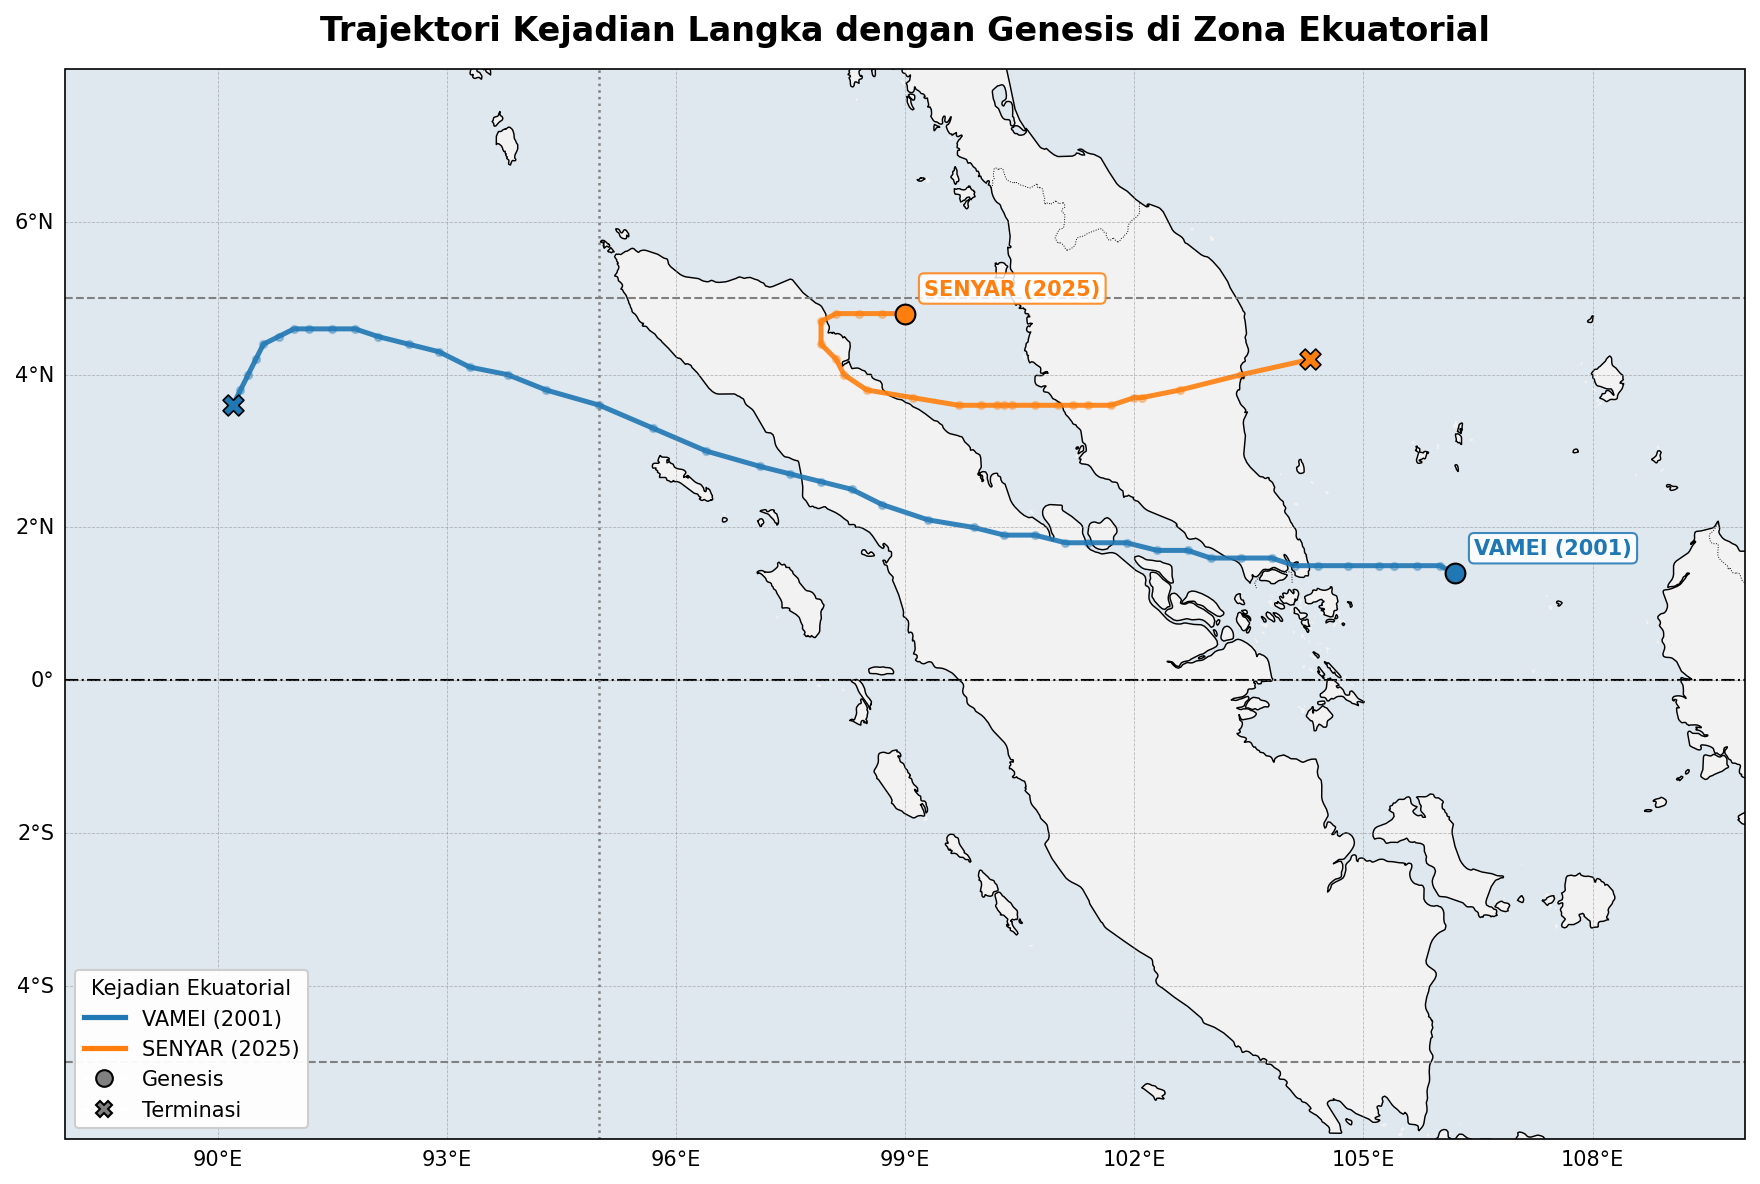

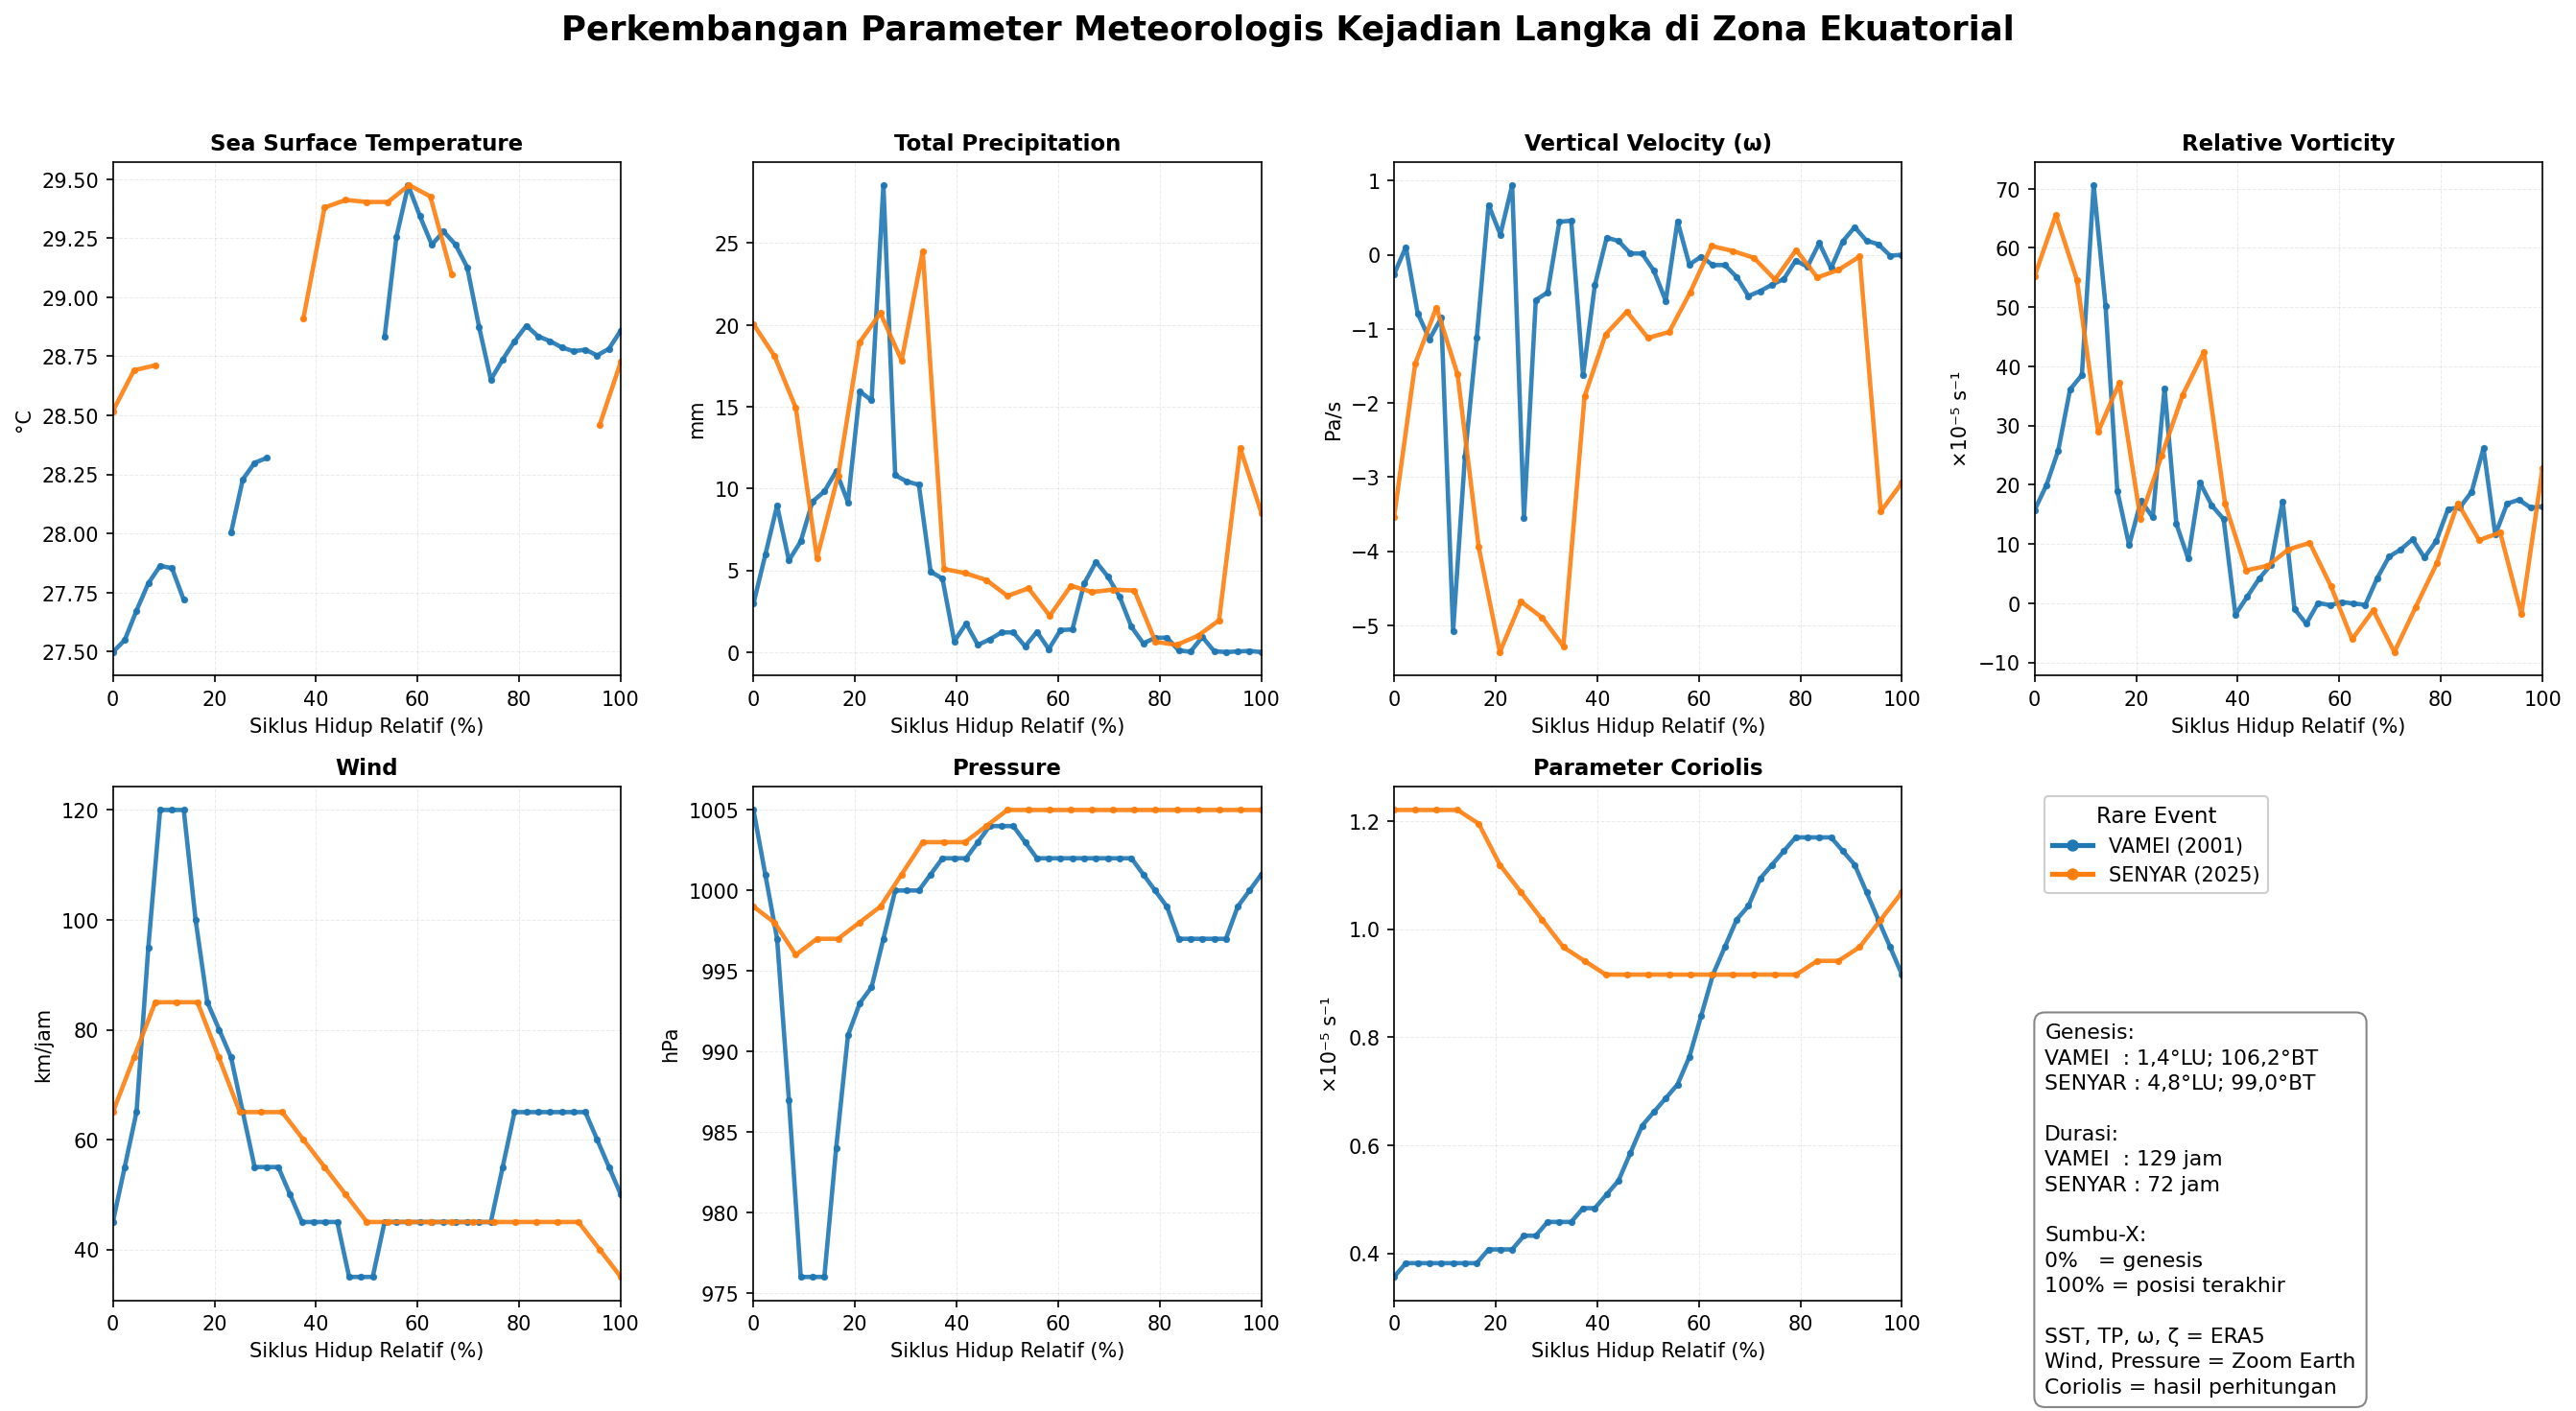


ANALISIS 3.1.3.4 SELESAI

Excel:
output_3_1_3\Hasil_3_1_3_4_Rare_Event_Ekuatorial.xlsx

Gambar 3.14:
output_3_1_3\Gambar_3.14_Trajektori_Rare_Event_Ekuatorial.png

Gambar 3.15:
output_3_1_3\Gambar_3.15_Meteorologi_Rare_Event_Ekuatorial.png


In [3]:
# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. FILE
# ============================================================

DATA_FILE = "Siklon_Tropis_ERA5_Extracted.xlsx"

CLUSTER_FILE = os.path.join(
    "output_3_1_2",
    "Hasil_3_1_2_2_Clustering.xlsx"
)

OUTPUT_DIR = "output_3_1_3"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_EXCEL = os.path.join(
    OUTPUT_DIR,
    "Hasil_3_1_3_4_Rare_Event_Ekuatorial.xlsx"
)


OUTPUT_G314 = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.14_Trajektori_Rare_Event_Ekuatorial.png"
)


OUTPUT_G315 = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.15_Meteorologi_Rare_Event_Ekuatorial.png"
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

EQ_MIN = -5
EQ_MAX = 5

YEAR_START = 2001
YEAR_END = 2025


# ============================================================
# 3. WARNA KASUS
# ============================================================

CASE_COLORS = {

    "VAMEI":
        "#1f77b4",

    "SENYAR":
        "#ff7f0e"

}


# ============================================================
# 4. VISUAL
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        10,

    "axes.titlesize":
        11,

    "axes.labelsize":
        10,

    "figure.dpi":
        150,

    "savefig.dpi":
        300

})


# ============================================================
# 5. CEK FILE
# ============================================================

if not os.path.exists(DATA_FILE):

    raise FileNotFoundError(
        f"File tidak ditemukan:\n{DATA_FILE}"
    )


# ============================================================
# 6. BACA DATA
# ============================================================

df = pd.read_excel(

    DATA_FILE,

    sheet_name="Sheet1",

    dtype={
        "SID": str
    }

)


df["SID"] = (

    df["SID"]
    .astype(str)
    .str.strip()

)


df["ISO_TIME"] = pd.to_datetime(

    df["ISO_TIME"],

    errors="coerce"

)


numeric_columns = [

    "LAT",
    "LON",
    "SEASON",

    "WIND_km/h",
    "PRESSURE_hPa",

    "era5_sst",
    "era5_tp",
    "era5_w",
    "era5_vo"

]


for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 7. CLEANING
# ============================================================

df = df.dropna(

    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]

).copy()


df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


df = df.drop_duplicates(

    subset=[
        "SID",
        "ISO_TIME"
    ],

    keep="first"

)


df = df.sort_values(

    [
        "SID",
        "ISO_TIME"
    ]

).reset_index(
    drop=True
)


# ============================================================
# 8. IDENTIFIKASI GENESIS SELURUH SID
# ============================================================

genesis_all = (

    df.drop_duplicates(

        subset="SID",

        keep="first"

    )

    .copy()

)


genesis_all = genesis_all[

    genesis_all["SEASON"].between(
        YEAR_START,
        YEAR_END
    )

].copy()


# ============================================================
# 9. SELEKSI DOMAIN PENELITIAN
# ============================================================

selected_genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX
    )

].copy()


# ============================================================
# 10. IDENTIFIKASI RARE EVENT EKUATORIAL
# ============================================================

equatorial_genesis = selected_genesis[

    selected_genesis["LAT"].between(
        EQ_MIN,
        EQ_MAX,
        inclusive="both"
    )

].copy()


print("=" * 80)

print(
    "KEJADIAN LANGKA DENGAN GENESIS DI ZONA EKUATORIAL"
)

print("=" * 80)


print(

    equatorial_genesis[

        [
            "SID",
            "NAME",
            "SEASON",
            "ISO_TIME",
            "LAT",
            "LON"
        ]

    ]

    .to_string(
        index=False
    )

)


print(
    "\nJumlah rare event =",
    len(
        equatorial_genesis
    )
)


if len(
    equatorial_genesis
) != 2:

    print(
        "\nPERINGATAN:"
        "\nJumlah kasus ekuatorial tidak sama dengan 2."
    )


# ============================================================
# 11. AMBIL SELURUH TRAJEKTORI KEDUA KASUS
# ============================================================
#
# Setelah genesis memenuhi domain,
# SELURUH trajektori tetap dipertahankan.
# ============================================================

rare_sids = (

    equatorial_genesis[
        "SID"
    ]

    .tolist()

)


rare_tracks = df[

    df["SID"].isin(
        rare_sids
    )

].copy()


rare_tracks = rare_tracks.sort_values(

    [
        "SID",
        "ISO_TIME"
    ]

).reset_index(
    drop=True
)


# ============================================================
# 12. KONVERSI PARAMETER
# ============================================================


# SST
rare_tracks["SST_C"] = (

    rare_tracks["era5_sst"]

    -

    273.15

)


# Total precipitation
rare_tracks["TP_mm"] = (

    rare_tracks["era5_tp"]

    *

    1000.0

)


# Vertical velocity
rare_tracks["Omega_Pa_s"] = (

    rare_tracks["era5_w"]

)


# Relative vorticity
rare_tracks["Vorticity_1e5"] = (

    rare_tracks["era5_vo"]

    *

    1e5

)


# Wind Zoom Earth
rare_tracks["Wind_kmh"] = (

    rare_tracks["WIND_km/h"]

)


# Pressure Zoom Earth
rare_tracks["Pressure_hPa"] = (

    rare_tracks["PRESSURE_hPa"]

)


# Coriolis
OMEGA_EARTH = 7.2921159e-5


rare_tracks["Coriolis_1e5"] = (

    2

    *

    OMEGA_EARTH

    *

    np.sin(

        np.radians(
            rare_tracks["LAT"]
        )

    )

    *

    1e5

)


# ============================================================
# 13. HITUNG WAKTU RELATIF
# ============================================================

processed_tracks = []


for sid, g in rare_tracks.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

        .copy()

    )


    start_time = (
        g["ISO_TIME"].iloc[0]
    )


    end_time = (
        g["ISO_TIME"].iloc[-1]
    )


    duration_hours = (

        (
            end_time
            -
            start_time
        )

        .total_seconds()

        /

        3600.0

    )


    g["Elapsed_Hours"] = (

        (
            g["ISO_TIME"]
            -
            start_time
        )

        .dt.total_seconds()

        /

        3600.0

    )


    if duration_hours > 0:

        g["Life_Cycle_Percent"] = (

            g["Elapsed_Hours"]

            /

            duration_hours

            *

            100

        )

    else:

        g["Life_Cycle_Percent"] = 0


    processed_tracks.append(
        g
    )


rare_tracks = pd.concat(

    processed_tracks,

    ignore_index=True

)


# ============================================================
# 14. FUNGSI HAVERSINE
# ============================================================

def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2
):


    R = 6371.0088


    lat1 = np.radians(
        lat1
    )

    lon1 = np.radians(
        lon1
    )

    lat2 = np.radians(
        lat2
    )

    lon2 = np.radians(
        lon2
    )


    dlat = (
        lat2
        -
        lat1
    )


    dlon = (
        lon2
        -
        lon1
    )


    a = (

        np.sin(
            dlat / 2
        ) ** 2

        +

        np.cos(
            lat1
        )

        *

        np.cos(
            lat2
        )

        *

        np.sin(
            dlon / 2
        ) ** 2

    )


    c = (

        2

        *

        np.arcsin(

            np.sqrt(
                a
            )

        )

    )


    return (
        R
        *
        c
    )


# ============================================================
# 15. HITUNG PANJANG TRAJEKTORI
# ============================================================

def calculate_track_length(
    g
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

    )


    lat = (
        g["LAT"]
        .to_numpy()
    )


    lon = (
        g["LON"]
        .to_numpy()
    )


    if len(
        g
    ) < 2:

        return 0


    distances = haversine_km(

        lat[:-1],
        lon[:-1],

        lat[1:],
        lon[1:]

    )


    return float(
        np.nansum(
            distances
        )
    )


# ============================================================
# 16. BACA INFORMASI CLUSTER
# ============================================================

if os.path.exists(
    CLUSTER_FILE
):


    cluster_assignment = pd.read_excel(

        CLUSTER_FILE,

        sheet_name="Assignment Cluster",

        dtype={
            "SID": str
        }

    )


    cluster_assignment["SID"] = (

        cluster_assignment["SID"]
        .astype(str)
        .str.strip()

    )


    cluster_assignment = (

        cluster_assignment[
            [
                "SID",
                "Cluster"
            ]
        ]

    )


else:


    cluster_assignment = pd.DataFrame(

        columns=[
            "SID",
            "Cluster"
        ]

    )


# ============================================================
# 17. TABEL 3.9
# KONDISI METEOROLOGIS TEPAT PADA GENESIS
# ============================================================

genesis_rare = (

    rare_tracks

    .sort_values(
        [
            "SID",
            "ISO_TIME"
        ]
    )

    .drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


genesis_rare = genesis_rare.merge(

    cluster_assignment,

    on="SID",

    how="left"

)


table_39 = genesis_rare[

    [
        "SID",
        "NAME",
        "SEASON",
        "LAT",
        "LON",
        "Cluster",

        "SST_C",
        "TP_mm",
        "Omega_Pa_s",
        "Vorticity_1e5",

        "Wind_kmh",
        "Pressure_hPa",
        "Coriolis_1e5"
    ]

].copy()


table_39 = table_39.rename(

    columns={

        "NAME":
            "Siklon",

        "SEASON":
            "Tahun",

        "LAT":
            "Latitude Genesis",

        "LON":
            "Longitude Genesis",

        "SST_C":
            "SST (°C)",

        "TP_mm":
            "TP (mm)",

        "Omega_Pa_s":
            "ω (Pa/s)",

        "Vorticity_1e5":
            "Vortisitas (×10⁻⁵ s⁻¹)",

        "Wind_kmh":
            "Wind (km/jam)",

        "Pressure_hPa":
            "Pressure (hPa)",

        "Coriolis_1e5":
            "Coriolis (×10⁻⁵ s⁻¹)"

    }

)


# ============================================================
# 18. TABEL 3.10
# RINGKASAN PERKEMBANGAN SEPANJANG TRAJEKTORI
# ============================================================

summary_records = []


for sid, g in rare_tracks.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

        .copy()

    )


    name = (
        g["NAME"].iloc[0]
    )


    year = int(
        g["SEASON"].iloc[0]
    )


    duration_hours = (

        g["Elapsed_Hours"]
        .max()

    )


    track_length = (
        calculate_track_length(
            g
        )
    )


    summary_records.append({

        "Siklon":
            name,

        "Tahun":
            year,

        "Durasi (jam)":
            duration_hours,

        "Panjang Trajektori (km)":
            track_length,

        "SST Rata-rata (°C)":
            g[
                "SST_C"
            ].mean(),

        "TP Rata-rata (mm)":
            g[
                "TP_mm"
            ].mean(),

        "ω Rata-rata (Pa/s)":
            g[
                "Omega_Pa_s"
            ].mean(),

        "ω Minimum (Pa/s)":
            g[
                "Omega_Pa_s"
            ].min(),

        "Vortisitas Rata-rata (×10⁻⁵ s⁻¹)":
            g[
                "Vorticity_1e5"
            ].mean(),

        "Vortisitas Maksimum (×10⁻⁵ s⁻¹)":
            g[
                "Vorticity_1e5"
            ].max(),

        "Wind Maksimum (km/jam)":
            g[
                "Wind_kmh"
            ].max(),

        "Pressure Minimum (hPa)":
            g[
                "Pressure_hPa"
            ].min()

    })


table_310 = pd.DataFrame(
    summary_records
)


# ============================================================
# 19. WAKTU WIND MAKSIMUM DAN PRESSURE MINIMUM
# ============================================================

intensity_records = []


for sid, g in rare_tracks.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

        .copy()

    )


    name = (
        g["NAME"].iloc[0]
    )


    # Wind maksimum
    wind_valid = g[
        g["Wind_kmh"].notna()
    ]


    wind_idx = (

        wind_valid[
            "Wind_kmh"
        ]

        .idxmax()

    )


    # Pressure minimum
    pressure_valid = g[
        g["Pressure_hPa"].notna()
    ]


    pressure_idx = (

        pressure_valid[
            "Pressure_hPa"
        ]

        .idxmin()

    )


    intensity_records.append({

        "Siklon":
            name,

        "Wind Maksimum":
            g.loc[
                wind_idx,
                "Wind_kmh"
            ],

        "Waktu Wind Maksimum":
            g.loc[
                wind_idx,
                "ISO_TIME"
            ],

        "Fase Wind Maksimum (%)":
            g.loc[
                wind_idx,
                "Life_Cycle_Percent"
            ],

        "Pressure Minimum":
            g.loc[
                pressure_idx,
                "Pressure_hPa"
            ],

        "Waktu Pressure Minimum":
            g.loc[
                pressure_idx,
                "ISO_TIME"
            ],

        "Fase Pressure Minimum (%)":
            g.loc[
                pressure_idx,
                "Life_Cycle_Percent"
            ]

    })


intensity_df = pd.DataFrame(
    intensity_records
)


# ============================================================
# 20. CETAK TABEL
# ============================================================

print("\n" + "=" * 120)

print(
    "TABEL 3.9 - KONDISI METEOROLOGIS PADA GENESIS"
)

print("=" * 120)


print(

    table_39

    .round(3)

    .to_string(
        index=False
    )

)


print("\n" + "=" * 120)

print(
    "TABEL 3.10 - RINGKASAN PERKEMBANGAN"
)

print("=" * 120)


print(

    table_310

    .round(3)

    .to_string(
        index=False
    )

)


# ============================================================
# 21. SIMPAN EXCEL
# ============================================================

with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    table_39.round(
        4
    ).to_excel(

        writer,

        sheet_name="Tabel 3.9",

        index=False

    )


    table_310.round(
        4
    ).to_excel(

        writer,

        sheet_name="Tabel 3.10",

        index=False

    )


    intensity_df.round(
        4
    ).to_excel(

        writer,

        sheet_name="Fase Intensitas",

        index=False

    )


    rare_tracks.to_excel(

        writer,

        sheet_name="Time Series Lengkap",

        index=False

    )


# ============================================================
# 22. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    for cell in ws[1]:


        cell.fill = (
            header_fill
        )


        cell.font = (
            header_font
        )


        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )


    for row in ws.iter_rows():


        for cell in row:


            cell.border = (
                thin_border
            )


            cell.alignment = Alignment(
                vertical="center"
            )


    for column_cells in ws.columns:


        column_letter = (
            column_cells[0]
            .column_letter
        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:


                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(
            max_length + 2,
            40
        )


wb.save(
    OUTPUT_EXCEL
)


# ============================================================
# ============================================================
#
#              GAMBAR 3.14
#
# TRAJEKTORI KHUSUS RARE EVENT EKUATORIAL
#
# ============================================================
# ============================================================


fig = plt.figure(
    figsize=(
        13,
        8
    )
)


ax = plt.axes(
    projection=ccrs.PlateCarree()
)


# ------------------------------------------------------------
# Tampilan regional
# ------------------------------------------------------------

ax.set_extent(

    [
        88,
        110,
        -6,
        8
    ],

    crs=ccrs.PlateCarree()

)


# ------------------------------------------------------------
# Background
# ------------------------------------------------------------

ax.add_feature(

    cfeature.OCEAN,

    facecolor="#dfe8ef"

)


ax.add_feature(

    cfeature.LAND,

    facecolor="#f2f2f2"

)


ax.add_feature(

    cfeature.COASTLINE,

    linewidth=0.7

)


ax.add_feature(

    cfeature.BORDERS,

    linewidth=0.45,

    linestyle=":"

)


# ------------------------------------------------------------
# Garis zona
# ------------------------------------------------------------

for lat_line in [
    -5,
    5
]:

    ax.plot(

        [
            88,
            110
        ],

        [
            lat_line,
            lat_line
        ],

        transform=ccrs.PlateCarree(),

        color="gray",

        linestyle="--",

        linewidth=1.0

    )


# Ekuator
ax.plot(

    [
        88,
        110
    ],

    [
        0,
        0
    ],

    transform=ccrs.PlateCarree(),

    color="black",

    linestyle="-.",

    linewidth=1.0

)


# Batas barat domain penelitian
ax.plot(

    [
        95,
        95
    ],

    [
        -6,
        8
    ],

    transform=ccrs.PlateCarree(),

    color="gray",

    linestyle=":",

    linewidth=1.2

)


# ------------------------------------------------------------
# Plot kedua kasus
# ------------------------------------------------------------

for sid, g in rare_tracks.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

    )


    name = str(
        g[
            "NAME"
        ].iloc[0]
    )


    year = int(
        g[
            "SEASON"
        ].iloc[0]
    )


    color = CASE_COLORS.get(

        name,

        "black"

    )


    # Track
    ax.plot(

        g["LON"],
        g["LAT"],

        transform=ccrs.PlateCarree(),

        color=color,

        linewidth=2.4,

        alpha=0.9,

        label=(
            f"{name} ({year})"
        )

    )


    # Titik track
    ax.scatter(

        g["LON"],
        g["LAT"],

        transform=ccrs.PlateCarree(),

        color=color,

        s=12,

        alpha=0.35

    )


    # Genesis
    ax.scatter(

        g[
            "LON"
        ].iloc[0],

        g[
            "LAT"
        ].iloc[0],

        transform=ccrs.PlateCarree(),

        color=color,

        marker="o",

        s=90,

        edgecolor="black",

        linewidth=1.0,

        zorder=10

    )


    # Terminasi
    ax.scatter(

        g[
            "LON"
        ].iloc[-1],

        g[
            "LAT"
        ].iloc[-1],

        transform=ccrs.PlateCarree(),

        color=color,

        marker="X",

        s=100,

        edgecolor="black",

        linewidth=0.8,

        zorder=10

    )


    # Label nama di genesis
    ax.text(

        g[
            "LON"
        ].iloc[0]
        +
        0.25,

        g[
            "LAT"
        ].iloc[0]
        +
        0.25,

        f"{name} ({year})",

        transform=ccrs.PlateCarree(),

        fontsize=10,

        fontweight="bold",

        color=color,

        bbox=dict(

            facecolor="white",

            edgecolor=color,

            alpha=0.85,

            boxstyle="round,pad=0.25"

        )

    )


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

gl = ax.gridlines(

    draw_labels=True,

    linewidth=0.4,

    color="gray",

    alpha=0.5,

    linestyle="--"

)


gl.top_labels = False
gl.right_labels = False


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_cases = [

    Line2D(

        [0],
        [0],

        color=CASE_COLORS[
            "VAMEI"
        ],

        linewidth=2.5,

        label="VAMEI (2001)"

    ),

    Line2D(

        [0],
        [0],

        color=CASE_COLORS[
            "SENYAR"
        ],

        linewidth=2.5,

        label="SENYAR (2025)"

    ),

    Line2D(

        [0],
        [0],

        marker="o",

        color="white",

        markerfacecolor="gray",

        markeredgecolor="black",

        markersize=8,

        label="Genesis"

    ),

    Line2D(

        [0],
        [0],

        marker="X",

        color="white",

        markerfacecolor="gray",

        markeredgecolor="black",

        markersize=8,

        label="Terminasi"

    )

]


ax.legend(

    handles=legend_cases,

    loc="lower left",

    frameon=True,

    framealpha=0.95,

    title="Kejadian Ekuatorial"

)


# ------------------------------------------------------------
# Judul
# ------------------------------------------------------------

ax.set_title(

    "Trajektori Kejadian Langka dengan Genesis di Zona Ekuatorial",

    fontsize=16,

    fontweight="bold",

    pad=14

)


plt.tight_layout()


plt.savefig(

    OUTPUT_G314,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


# ============================================================
# ============================================================
#
#              GAMBAR 3.15
#
# PERKEMBANGAN PARAMETER METEOROLOGIS
#
# ============================================================
# ============================================================


PLOT_PARAMETERS = [

    (
        "SST_C",
        "Sea Surface Temperature",
        "°C"
    ),

    (
        "TP_mm",
        "Total Precipitation",
        "mm"
    ),

    (
        "Omega_Pa_s",
        "Vertical Velocity (ω)",
        "Pa/s"
    ),

    (
        "Vorticity_1e5",
        "Relative Vorticity",
        "×10⁻⁵ s⁻¹"
    ),

    (
        "Wind_kmh",
        "Wind",
        "km/jam"
    ),

    (
        "Pressure_hPa",
        "Pressure",
        "hPa"
    ),

    (
        "Coriolis_1e5",
        "Parameter Coriolis",
        "×10⁻⁵ s⁻¹"
    )

]


fig, axes = plt.subplots(

    2,
    4,

    figsize=(
        18,
        10
    )

)


axes = axes.flatten()


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for ax, (
    variable,
    title,
    unit
) in zip(

    axes,
    PLOT_PARAMETERS

):


    for sid, g in rare_tracks.groupby(
        "SID"
    ):


        g = (

            g.sort_values(
                "Life_Cycle_Percent"
            )

        )


        name = str(
            g[
                "NAME"
            ].iloc[0]
        )


        year = int(
            g[
                "SEASON"
            ].iloc[0]
        )


        color = CASE_COLORS.get(
            name,
            "black"
        )


        ax.plot(

            g[
                "Life_Cycle_Percent"
            ],

            g[
                variable
            ],

            color=color,

            linewidth=2.2,

            marker="o",

            markersize=2.5,

            alpha=0.9,

            label=(
                f"{name} ({year})"
            )

        )


    ax.set_title(

        title,

        fontweight="bold"

    )


    ax.set_xlabel(

        "Siklus Hidup Relatif (%)"

    )


    ax.set_ylabel(
        unit
    )


    ax.set_xlim(
        0,
        100
    )


    ax.set_xticks(

        [
            0,
            20,
            40,
            60,
            80,
            100
        ]

    )


    ax.grid(

        linestyle="--",

        linewidth=0.5,

        alpha=0.25

    )


# ------------------------------------------------------------
# Panel informasi
# ------------------------------------------------------------

axes[
    7
].axis(
    "off"
)


legend_handles = [

    Line2D(

        [0],
        [0],

        color=CASE_COLORS[
            "VAMEI"
        ],

        linewidth=2.5,

        marker="o",

        markersize=5,

        label="VAMEI (2001)"

    ),

    Line2D(

        [0],
        [0],

        color=CASE_COLORS[
            "SENYAR"
        ],

        linewidth=2.5,

        marker="o",

        markersize=5,

        label="SENYAR (2025)"

    )

]


axes[
    7
].legend(

    handles=legend_handles,

    loc="upper left",

    title="Rare Event",

    fontsize=10,

    title_fontsize=11,

    frameon=True,

    framealpha=0.95

)


info_text = (

    "Genesis:\n"
    "VAMEI  : 1,4°LU; 106,2°BT\n"
    "SENYAR : 4,8°LU; 99,0°BT\n\n"

    "Durasi:\n"
    "VAMEI  : 129 jam\n"
    "SENYAR : 72 jam\n\n"

    "Sumbu-X:\n"
    "0%   = genesis\n"
    "100% = posisi terakhir\n\n"

    "SST, TP, ω, ζ = ERA5\n"
    "Wind, Pressure = Zoom Earth\n"
    "Coriolis = hasil perhitungan"

)


axes[
    7
].text(

    0.02,
    0.54,

    info_text,

    transform=axes[
        7
    ].transAxes,

    va="top",

    fontsize=10.5,

    linespacing=1.4,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        boxstyle="round,pad=0.5",

        alpha=0.95

    )

)


fig.suptitle(

    "Perkembangan Parameter Meteorologis Kejadian Langka di Zona Ekuatorial",

    fontsize=17,

    fontweight="bold",

    y=0.98

)


plt.tight_layout(

    rect=[
        0,
        0,
        1,
        0.95
    ]

)


plt.savefig(

    OUTPUT_G315,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


# ============================================================
# 23. OUTPUT AKHIR
# ============================================================

print("\n" + "=" * 90)

print(
    "ANALISIS 3.1.3.4 SELESAI"
)

print("=" * 90)


print(
    "\nExcel:"
)

print(
    OUTPUT_EXCEL
)


print(
    "\nGambar 3.14:"
)

print(
    OUTPUT_G314
)


print(
    "\nGambar 3.15:"
)

print(
    OUTPUT_G315
)


print("=" * 90)

PROBABILITAS EMPIRIS BERDASARKAN ZONA
Jumlah total kejadian: 392

Jumlah berdasarkan zona:
Zona
Utara         354
Ekuatorial      2
Selatan        36
Name: count, dtype: int64

RARE EVENT EKUATORIAL
N ekuatorial       = 2
N total            = 392
P(E)               = 0.005102
Persentase         = 0.5102%
Setara sekitar     = 1 dari 196 kejadian


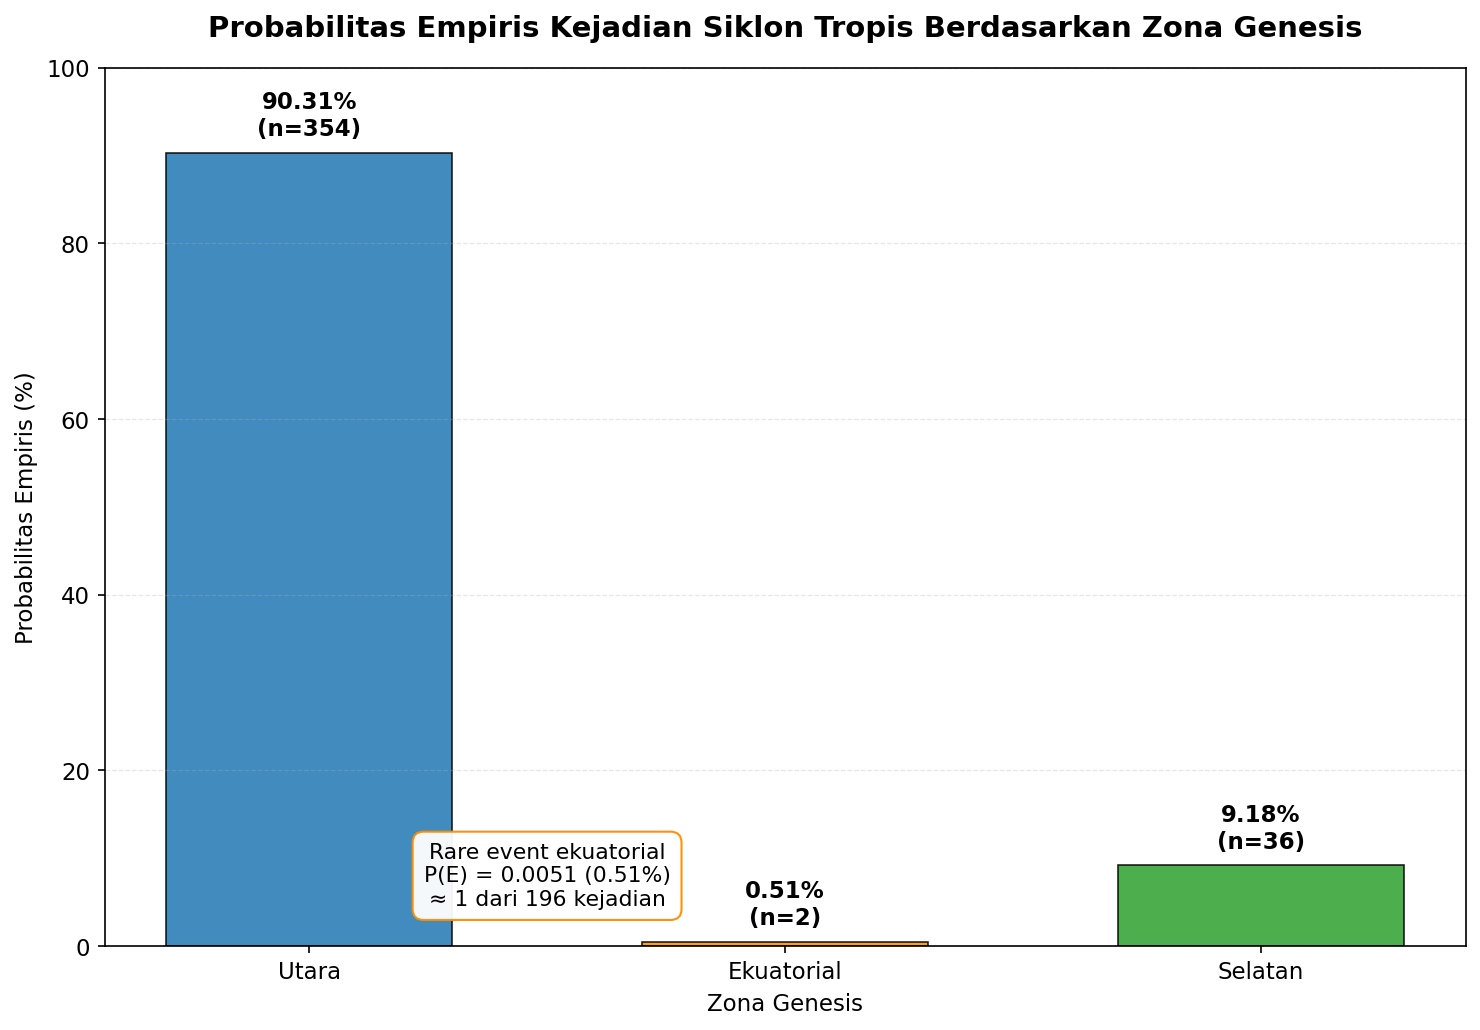


TABEL 3.11
      Zona  Jumlah Kejadian  Probabilitas Empiris  Persentase (%)
     Utara              354              0.903061           90.31
Ekuatorial                2              0.005102            0.51
   Selatan               36              0.091837            9.18

Excel:
output_3_1_4\Hasil_3_1_4_Probabilitas_Empiris.xlsx

Gambar 3.16:
output_3_1_4\Gambar_3.16_Probabilitas_Empiris_Zona.png


In [4]:
# ============================================================
# 0. IMPORT
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. FILE
# ============================================================

DATA_FILE = "Siklon_Tropis_ERA5_Extracted.xlsx"

OUTPUT_DIR = "output_3_1_4"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_EXCEL = os.path.join(
    OUTPUT_DIR,
    "Hasil_3_1_4_Probabilitas_Empiris.xlsx"
)


OUTPUT_FIGURE = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.16_Probabilitas_Empiris_Zona.png"
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

EQ_MIN = -5
EQ_MAX = 5

YEAR_START = 2001
YEAR_END = 2025


# ============================================================
# 3. URUTAN DAN WARNA
# ============================================================

ZONE_ORDER = [
    "Utara",
    "Ekuatorial",
    "Selatan"
]


ZONE_COLORS = {
    "Utara": "#1f77b4",
    "Ekuatorial": "#ff8c00",
    "Selatan": "#2ca02c"
}


# ============================================================
# 4. PENGATURAN GRAFIK
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        11,

    "axes.titlesize":
        13,

    "axes.labelsize":
        11,

    "figure.dpi":
        150,

    "savefig.dpi":
        300

})


# ============================================================
# 5. BACA DATA
# ============================================================

df = pd.read_excel(
    DATA_FILE,
    sheet_name="Sheet1",
    dtype={
        "SID": str
    }
)


df["SID"] = (
    df["SID"]
    .astype(str)
    .str.strip()
)


df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)


for col in [
    "LAT",
    "LON",
    "SEASON"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 6. CLEANING
# ============================================================

df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 7. IDENTIFIKASI GENESIS
# ============================================================
#
# Genesis = titik pertama setiap SID.
# ============================================================

genesis_all = (

    df.drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


# ============================================================
# 8. FILTER PERIODE
# ============================================================

genesis_all = genesis_all[

    genesis_all["SEASON"].between(
        YEAR_START,
        YEAR_END
    )

].copy()


# ============================================================
# 9. FILTER DOMAIN
# ============================================================

genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX,
        inclusive="both"
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX,
        inclusive="both"
    )

].copy()


# ============================================================
# 10. KLASIFIKASI ZONA
# ============================================================

def classify_zone(lat):

    if EQ_MIN <= lat <= EQ_MAX:

        return "Ekuatorial"

    elif lat > EQ_MAX:

        return "Utara"

    else:

        return "Selatan"


genesis["Zona"] = (
    genesis["LAT"]
    .apply(
        classify_zone
    )
)


# ============================================================
# 11. QUALITY CONTROL
# ============================================================

N_TOTAL = len(
    genesis
)


print("=" * 80)
print("PROBABILITAS EMPIRIS BERDASARKAN ZONA")
print("=" * 80)


print(
    "Jumlah total kejadian:",
    N_TOTAL
)


print("\nJumlah berdasarkan zona:")

print(

    genesis["Zona"]

    .value_counts()

    .reindex(
        ZONE_ORDER,
        fill_value=0
    )

)


if N_TOTAL != 392:

    print(
        "\nPERINGATAN:"
        "\nJumlah kejadian tidak sama dengan 392."
    )


# ============================================================
# 12. HITUNG JUMLAH KEJADIAN
# ============================================================

zone_counts = (

    genesis["Zona"]

    .value_counts()

    .reindex(
        ZONE_ORDER,
        fill_value=0
    )

)


# ============================================================
# 13. HITUNG PROBABILITAS EMPIRIS
# ============================================================

probability_records = []


for zone in ZONE_ORDER:


    n_zone = int(
        zone_counts[
            zone
        ]
    )


    probability = (

        n_zone
        /
        N_TOTAL

    )


    percentage = (

        probability
        *
        100

    )


    # Rasio terhadap jumlah kejadian:
    # misal ekuatorial ~ 1 dari 196 kejadian
    if n_zone > 0:

        events_per_one = (

            N_TOTAL
            /
            n_zone

        )

    else:

        events_per_one = np.nan


    probability_records.append({

        "Zona":
            zone,

        "Jumlah Kejadian":
            n_zone,

        "Probabilitas Empiris":
            probability,

        "Persentase (%)":
            percentage,

        "Setara 1 dari N Kejadian":
            events_per_one

    })


probability_df = pd.DataFrame(
    probability_records
)


# ============================================================
# 14. TABEL 3.11
# ============================================================

table_311 = probability_df[

    [
        "Zona",
        "Jumlah Kejadian",
        "Probabilitas Empiris",
        "Persentase (%)"
    ]

].copy()


# ============================================================
# 15. PROBABILITAS RARE EVENT
# ============================================================

P_EQUATORIAL = (

    probability_df.loc[

        probability_df["Zona"]
        ==
        "Ekuatorial",

        "Probabilitas Empiris"

    ]

    .iloc[0]

)


N_EQUATORIAL = (

    probability_df.loc[

        probability_df["Zona"]
        ==
        "Ekuatorial",

        "Jumlah Kejadian"

    ]

    .iloc[0]

)


ratio_equatorial = (

    N_TOTAL
    /
    N_EQUATORIAL

)


print("\n" + "=" * 80)

print("RARE EVENT EKUATORIAL")

print("=" * 80)


print(
    f"N ekuatorial       = {N_EQUATORIAL}"
)


print(
    f"N total            = {N_TOTAL}"
)


print(
    f"P(E)               = {P_EQUATORIAL:.6f}"
)


print(
    f"Persentase         = {P_EQUATORIAL * 100:.4f}%"
)


print(
    f"Setara sekitar     = 1 dari {ratio_equatorial:.0f} kejadian"
)


# ============================================================
# 16. FREKUENSI TAHUNAN PENDUKUNG
# ============================================================
#
# Ini BUKAN probabilitas empiris utama.
# Hanya statistik pendukung.
# ============================================================

N_YEARS = (

    YEAR_END
    -
    YEAR_START
    +
    1

)


annual_frequency_records = []


for zone in ZONE_ORDER:


    n_zone = int(
        zone_counts[
            zone
        ]
    )


    annual_frequency_records.append({

        "Zona":
            zone,

        "Jumlah Kejadian":
            n_zone,

        "Jumlah Tahun":
            N_YEARS,

        "Rata-rata Kejadian per Tahun":
            (
                n_zone
                /
                N_YEARS
            )

    })


annual_frequency_df = pd.DataFrame(
    annual_frequency_records
)


# ============================================================
# 17. DAFTAR KEJADIAN EKUATORIAL
# ============================================================

equatorial_events = genesis[

    genesis["Zona"]
    ==
    "Ekuatorial"

][

    [
        "SID",
        "NAME",
        "SEASON",
        "ISO_TIME",
        "LAT",
        "LON"
    ]

].copy()


# ============================================================
# 18. SIMPAN EXCEL
# ============================================================

with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    table_311.round(
        6
    ).to_excel(

        writer,

        sheet_name="Tabel 3.11",

        index=False

    )


    probability_df.round(
        6
    ).to_excel(

        writer,

        sheet_name="Probabilitas Lengkap",

        index=False

    )


    annual_frequency_df.round(
        4
    ).to_excel(

        writer,

        sheet_name="Frekuensi Tahunan",

        index=False

    )


    equatorial_events.to_excel(

        writer,

        sheet_name="Rare Event Ekuatorial",

        index=False

    )


    genesis.to_excel(

        writer,

        sheet_name="Data Genesis",

        index=False

    )


# ============================================================
# 19. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    for cell in ws[1]:

        cell.fill = header_fill

        cell.font = header_font

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )


    for row in ws.iter_rows():

        for cell in row:

            cell.border = thin_border

            cell.alignment = Alignment(
                vertical="center"
            )


    for column_cells in ws.columns:


        column_letter = (
            column_cells[0]
            .column_letter
        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:

                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(
            max_length + 2,
            35
        )


wb.save(
    OUTPUT_EXCEL
)


# ============================================================
# 20. GAMBAR 3.16
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10,
        7
    )
)


zones = (
    probability_df[
        "Zona"
    ].tolist()
)


percentages = (
    probability_df[
        "Persentase (%)"
    ].to_numpy()
)


colors = [

    ZONE_COLORS[
        zone
    ]

    for zone in zones

]


bars = ax.bar(

    zones,

    percentages,

    color=colors,

    width=0.60,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.8

)


# ============================================================
# 21. LABEL NILAI
# ============================================================

for bar, probability, percentage, count in zip(

    bars,

    probability_df[
        "Probabilitas Empiris"
    ],

    probability_df[
        "Persentase (%)"
    ],

    probability_df[
        "Jumlah Kejadian"
    ]

):


    y = (
        bar.get_height()
    )


    ax.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        y
        +
        1.4,

        (
            f"{percentage:.2f}%\n"
            f"(n={count})"
        ),

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )


# ============================================================
# 22. FORMAT PLOT
# ============================================================

ax.set_ylim(
    0,
    100
)


ax.set_ylabel(
    "Probabilitas Empiris (%)"
)


ax.set_xlabel(
    "Zona Genesis"
)


ax.set_title(

    "Probabilitas Empiris Kejadian Siklon Tropis Berdasarkan Zona Genesis",

    fontsize=14,

    fontweight="bold",

    pad=15

)


ax.grid(

    axis="y",

    linestyle="--",

    linewidth=0.6,

    alpha=0.30

)


# Catatan khusus rare event
ax.text(

    0.5,
    8,

    (
        "Rare event ekuatorial\n"
        f"P(E) = {P_EQUATORIAL:.4f} "
        f"({P_EQUATORIAL * 100:.2f}%)\n"
        f"≈ 1 dari {ratio_equatorial:.0f} kejadian"
    ),

    ha="center",

    va="center",

    fontsize=10.5,

    bbox=dict(

        facecolor="white",

        edgecolor=ZONE_COLORS[
            "Ekuatorial"
        ],

        boxstyle="round,pad=0.5",

        alpha=0.95

    )

)


plt.tight_layout()


plt.savefig(

    OUTPUT_FIGURE,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


# ============================================================
# 23. OUTPUT TERMINAL
# ============================================================

print("\n" + "=" * 90)

print(
    "TABEL 3.11"
)

print("=" * 90)


print(

    table_311

    .round(
        {
            "Probabilitas Empiris": 6,
            "Persentase (%)": 2
        }
    )

    .to_string(
        index=False
    )

)


print("\nExcel:")

print(
    OUTPUT_EXCEL
)


print("\nGambar 3.16:")

print(
    OUTPUT_FIGURE
)


print("=" * 90)